In [1]:
!pip install torch
!pip install torch-geometric

  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nvjitlink_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached nvidia_cublas_

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.nn as pyg_nn

class AdvancedTemporalGraphNetwork(nn.Module):
    def __init__(self, num_features, hidden_channels, num_nodes, dropout=0):
        super(AdvancedTemporalGraphNetwork, self).__init__()
        self.init_params = {
            'num_features': num_features,
            'hidden_channels': hidden_channels,
            'num_nodes': num_nodes,
            'dropout': dropout
        }
        self.feature_reducer = nn.Linear(num_features, hidden_channels)
        self.graph_conv1 = pyg_nn.SAGEConv(hidden_channels, hidden_channels)
        self.graph_conv2 = pyg_nn.SAGEConv(hidden_channels, hidden_channels)
        self.dropout = nn.Dropout(p=dropout)
        self.temporal_lstm = nn.LSTM(
            input_size=hidden_channels,
            hidden_size=hidden_channels,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=hidden_channels,
            num_heads=2,
            batch_first=True,
            dropout=dropout
        )

        # Prediction head now outputs only 1 value for pm2p5
        self.prediction_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_channels // 2, 1)  # Output size set to 1
        )

    # Update your model's forward method to handle the sequence properly:
    def forward(self, x, edge_index, time_sequence):
        """
        Forward pass through the network
        Args:
          x: Input features tensor [batch_size, num_nodes, num_features]
          edge_index: Graph connectivity [2, num_edges]
          time_sequence: Temporal sequence data [batch_size, sequence_length, num_features]
        Returns:
          predictions: PM2.5 predictions [batch_size, 1]
        """
        num_features = self.init_params['num_features']
        num_nodes = self.init_params['num_nodes']
        batch_size = x.shape[0]
        if x is None:
          x = torch.randn(batch_size, num_nodes, num_features, device=edge_index.device)
        x = x.float()

        time_sequence = time_sequence.float()

        # Reshape the input tensor to match the expected shape
        x_flat = x.view(-1, num_features)  # Flatten the batch and nodes dimensions

        # Apply feature reduction and graph convolutions
        spatial_features = self.feature_reducer(x_flat)
        spatial_features = self.dropout(F.relu(self.graph_conv1(spatial_features, edge_index)))
        spatial_features = self.dropout(F.relu(self.graph_conv2(spatial_features, edge_index)))

        # Reshape back to sequence format
        spatial_features = spatial_features.view(batch_size, num_nodes, -1)

        # Process temporal features
        # Reshape and reduce temporal features
        time_flat = time_sequence.view(-1, num_features)
        temporal_features = self.feature_reducer(time_flat)
        temporal_features = temporal_features.view(batch_size, -1, temporal_features.size(-1))

        # Apply LSTM and attention
        lstm_out, _ = self.temporal_lstm(temporal_features)
        attn_out, _ = self.temporal_attention(lstm_out, lstm_out, lstm_out)

        # Combine spatial and temporal features
        # Take the mean of spatial features across nodes and add to temporal features
        combined_features = attn_out[:, -1, :] + spatial_features.mean(dim=1)

        # Generate final predictions
        predictions = self.prediction_head(combined_features)

        return predictions

print(f'Model Compiled')

Model Compiled


Process

In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')
# Load and preprocess the data
root_path = '/content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG'


path= f'{root_path}/input/120'
best_model_path=f'{root_path}/best_model'
plot_path=f'{root_path}/plot'

combined_df =None

print(f'Drive Mounted - Input Path assigned {path}')
print(f'Drive Mounted - Best Model Path assigned {best_model_path}')
print(f'Drive Mounted - Plot Path assigned {plot_path}')

dir_path = f'{best_model_path}'
dir_list = os.listdir(dir_path)
print(f'dir_list: {dir_list}')

Mounted at /content/drive
Drive Mounted - Input Path assigned /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120
Drive Mounted - Best Model Path assigned /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/best_model
Drive Mounted - Plot Path assigned /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/plot
dir_list: ['best_model.pth']


In [4]:
import pandas as pd
# Get the list of all files and directories
def list_files_of_a_dir(foldername):
    dir_path = f'{foldername}'
    dir_list = os.listdir(dir_path)
    return dir_list

dir_list = list_files_of_a_dir(path)
print(f"Files and directories in {path}")
for a in dir_list:
  print(a)

Files and directories in /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120
station_list_20241225.csv
Johannesburg_Slovoville_1.csv
Johannesburg_Thulani_2.csv
Johannesburg_Ikusasalethu_Sec_3.csv
Johannesburg_Siyabonga_Secondary_4.csv
Johannesburg_Nkone_Maruping_Pry_5.csv
Johannesburg_J.B_Marks_Secondary_6.csv
Johannesburg_Origin_Center_1_7.csv
Johannesburg_Origin_Center_2_8.csv
Johannesburg_iThemba_Labs_1_9.csv
Johannesburg_iThemba_Labs_2_10.csv
Johannesburg_Braamfischer_11.csv
Johannesburg_Milpark_NetCare_2_12.csv
Johannesburg_Milpark_Netcare_1_13.csv


In [5]:
import os
import pandas as pd

def load_all_csv():
    input_dir = f'{path}'
    print(f'input_dir:{input_dir}')
    list_file = list_files_of_a_dir(input_dir)
    dataframes = []
    print("Step 02: Loading selected columns from all CSVs into DataFrames")
    selected_columns = ['sensor_id', 'timestamp', 'temperature', 'humidity', 'longitude', 'latitude', 'pm2p5']
    i = 0
    for f_name in list_file:
        if f_name.endswith(".csv") and "station" not in f_name.lower():
            # Build the full file path
            csv_path = os.path.join(input_dir, f_name)

            try:
                # Read the CSV file into a DataFrame with selected columns
                df = pd.read_csv(csv_path, usecols=selected_columns)
                dataframes.append(df)
                print(f"    {i}.    Loaded: {csv_path}")
                i += 1
            except Exception as e:
                print(f"Error reading {csv_path}: {e}")

    if dataframes:
        combined_df = pd.concat(dataframes, ignore_index=True)
        combined_df = combined_df[selected_columns]  # Ensure columns are in the specified order
        print(combined_df.columns.tolist())
        print(f"Step 03: Clubbed selected columns from all CSVs into a dataset. Dataset Shape: {combined_df.shape}")
    else:
        print("No valid CSV files found.")
        combined_df = None

    return combined_df

df = load_all_csv()

print(df)



input_dir:/content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120
Step 02: Loading selected columns from all CSVs into DataFrames
    0.    Loaded: /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120/Johannesburg_Slovoville_1.csv
    1.    Loaded: /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120/Johannesburg_Thulani_2.csv
    2.    Loaded: /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120/Johannesburg_Ikusasalethu_Sec_3.csv
    3.    Loaded: /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120/Johannesburg_Siyabonga_Secondary_4.csv
    4.    Loaded: /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120/Johannesburg_Nkone_Maruping_Pry_5.csv
    5.    Loaded: /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120/Johannesburg_J.B_Marks_Secondary_6.csv
    6.    Loaded: /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/input/120

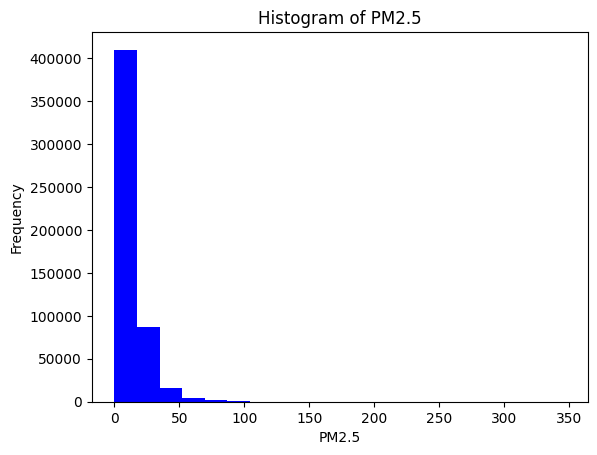

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['pm2p5'], bins=20, color='blue')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.title('Histogram of PM2.5')

plt.savefig(f'{plot_path}/histogram_before_outliers_plot.png')
plt.show()
plt.close()

In [7]:
import pandas as pd

def find_outliers_iqr(data, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    print(f'IQR : {IQR}')
    lower_bound = Q1 - 1.5 * IQR
    print(f'lower_bound : {lower_bound}')
    upper_bound = Q3 + 1.5 * IQR
    print(f'upper_bound : {upper_bound}')
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Example usage:
outliers = find_outliers_iqr(df, 'pm2p5')
print(outliers)

IQR : 10.98
lower_bound : -11.41
upper_bound : 32.51
              sensor_id                 timestamp  temperature  humidity  \
602     350976650270090  2024-12-07T04:09:02.000Z        28.29     21.38   
603     350976650270090  2024-12-07T03:18:46.000Z        27.05     22.30   
1076    350976650270090  2024-11-30T19:07:57.000Z        27.40     25.35   
1077    350976650270090  2024-11-30T19:05:07.000Z        27.42     25.41   
1078    350976650270090  2024-11-30T19:02:33.000Z        27.57     25.13   
...                 ...                       ...          ...       ...   
519743  350976650262543  2024-08-28T15:28:27.000Z        21.59     22.59   
519744  350976650262543  2024-08-28T15:25:47.000Z        21.46     22.71   
519745  350976650262543  2024-08-28T15:21:47.000Z        21.78     22.26   
519746  350976650262543  2024-08-28T15:15:30.000Z        22.04     22.12   
519747  350976650262543  2024-08-28T15:11:28.000Z        22.35     21.99   

        longitude   latitude  pm2p

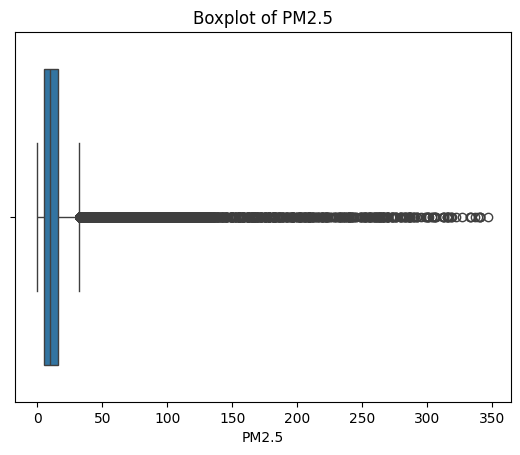

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df':
sns.boxplot(x=df['pm2p5'])  # Use seaborn for a more visually appealing boxplot
plt.xlabel('PM2.5')
plt.title('Boxplot of PM2.5')
plt.savefig(f'{plot_path}/boxplot_before_outliers_plot.png')
plt.show()

plt.close()

In [9]:
top_50_pm2p5 = df.sort_values(by=['pm2p5'], ascending=True).head(50000)['pm2p5']
print(top_50_pm2p5)

292153    0.0
291998    0.0
292196    0.0
291997    0.0
291996    0.0
         ... 
189013    3.0
364086    3.0
374429    3.0
89901     3.0
89902     3.0
Name: pm2p5, Length: 50000, dtype: float64


In [10]:
top_50_pm2p5 = df.sort_values(by=['pm2p5'], ascending=False).head(15000)['pm2p5']
print(top_50_pm2p5)

420141    347.07
383758    341.04
420138    341.02
265893    341.00
515980    339.00
           ...  
69192      41.01
467591     41.01
216943     41.01
173180     41.01
42982      41.01
Name: pm2p5, Length: 15000, dtype: float64


In [11]:
# Importing
import sklearn
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

# Create the dataframe
df_pm2p5 =  df.copy()
df_pm2p5.head()
print("Old Shape: ", df_pm2p5.shape)

''' Detection '''
# IQR
# Calculate the upper and lower limits
Q1 = df_pm2p5['pm2p5'].quantile(0.25)
Q3 = df_pm2p5['pm2p5'].quantile(0.75)
IQR = Q3 - Q1
print(f'IQR:{IQR}')
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

# Create arrays of Boolean values indicating the outlier rows
upper_array = np.where(df_pm2p5['pm2p5'] >= upper)[0]
lower_array = np.where(df_pm2p5['pm2p5'] <= lower)[0]

# Removing the outliers
df_pm2p5.drop(index=upper_array, inplace=True)
df_pm2p5.drop(index=lower_array, inplace=True)
df_pm2p5 = df_pm2p5[df_pm2p5['pm2p5'] > 0]

# Print the new shape of the DataFrame
print("New Shape: ", df_pm2p5.shape)



Old Shape:  (519748, 7)
IQR:10.98
New Shape:  (492508, 7)


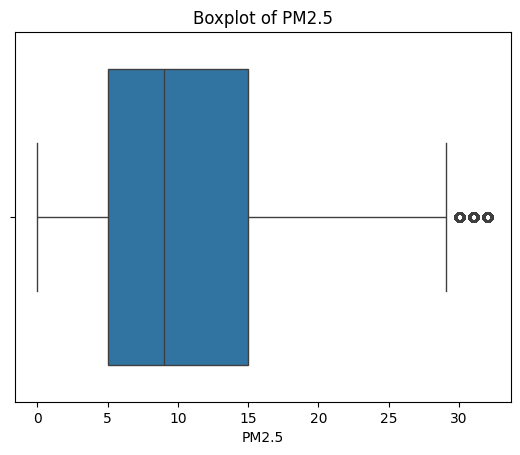

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df':
sns.boxplot(x=df_pm2p5['pm2p5'])  # Use seaborn for a more visually appealing boxplot
plt.xlabel('PM2.5')
plt.title('Boxplot of PM2.5')
plt.savefig(f'{plot_path}/boxplot_after_outliers_plot.png')
plt.show()

plt.close()

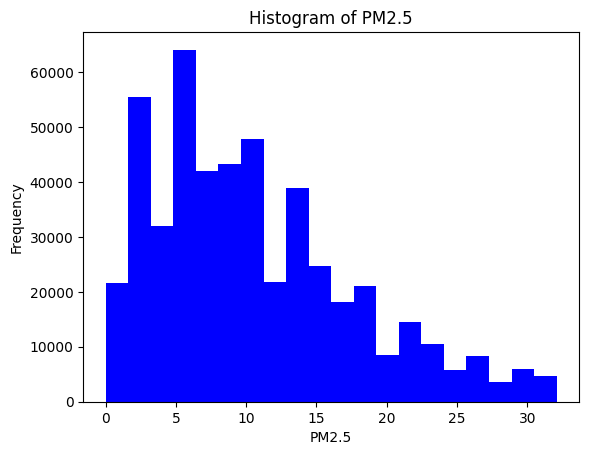

In [13]:
import matplotlib.pyplot as plt

plt.hist(df_pm2p5['pm2p5'], bins=20, color='blue')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.title('Histogram of PM2.5')
plt.savefig(f'{plot_path}/histogram_after_outliers_plot.png')

plt.show()
plt.close()

In [14]:
top_50_pm2p5 = df_pm2p5.sort_values(by=['pm2p5'], ascending=True).head(50000)['pm2p5']
print(top_50_pm2p5)

292021    0.01
115037    0.01
115028    0.01
115016    0.01
105752    0.01
          ... 
123168    3.00
100705    3.00
24628     3.00
237434    3.00
234903    3.00
Name: pm2p5, Length: 50000, dtype: float64


In [15]:
top_50_pm2p5 = df_pm2p5.sort_values(by=['pm2p5'], ascending=False).head(15000)['pm2p5']
print(top_50_pm2p5)

507017    32.09
410462    32.09
163195    32.09
35468     32.09
506613    32.09
          ...  
35113     27.07
490842    27.07
81460     27.07
506599    27.07
377492    27.07
Name: pm2p5, Length: 15000, dtype: float64


In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import torch
from torch import nn, optim
import matplotlib.pyplot as plt

df = df_pm2p5.copy()
print(df.columns)
#pd.read_csv(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_month'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second

df = df.drop(columns=['timestamp'])

columns = list(df.columns)
columns.remove('pm2p5')
#columns.remove('_id')
columns.append('pm2p5')
df = df[columns]

# Define constants
n_steps = 5
scalers_X, scalers_y = {}, {}
sensor_ids = df['sensor_id'].unique()
print(f'sensor_ids : {sensor_ids}')
# Create sequences and scale data by sensor_id
def scale_features(df, sensor_id):
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    df_sensor = df[df['sensor_id'] == sensor_id]
    print(f'scale_features->df_sensor==>')
    print(f'{df_sensor}')
    print(f'<==')
    X = df_sensor.drop(columns=['sensor_id', 'pm2p5']).to_numpy()
    y = df_sensor['pm2p5'].to_numpy()

    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
    scalers_X[sensor_id] = scaler_X
    scalers_y[sensor_id] = scaler_y
  #  print(f'scalers_X==>{scalers_X}')
  #  print(f'scalers_y==>{scalers_y}')

  #  print(f'X_scaled[sensor_id={sensor_id}]:{X_scaled}')
  #  print(f'y_scaled[sensor_id={sensor_id}]:{y_scaled}')
    return X_scaled, y_scaled

def create_sequences(X, y, n_steps):
    Xs, ys = [], []
    for i in range(len(X) - n_steps + 1):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps-1])
    return np.array(Xs), np.array(ys)

# Scale and sequence the data
X_seq_combined, y_seq_combined = [], []
print(f'before for loop sensor_ids:{sensor_ids}')

for sensor_id in sensor_ids:
    print(f'in for loop sensor_id:{sensor_id}')
    X_scaled, y_scaled = scale_features(df, sensor_id)
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, n_steps)
    X_seq_combined.append(X_seq)
    y_seq_combined.append(y_seq)

print(f'0. Length X_seq_combined:{len(X_seq_combined)}')
print(f'0. Length y_seq_combined:{len(y_seq_combined)}')

X_seq_combined = np.concatenate(X_seq_combined, axis=0)
y_seq_combined = np.concatenate(y_seq_combined, axis=0)

print('Flattening the 2 lists X_seq_combined, y_seq_combined')
print(f'1. Length X_seq_combined:{len(X_seq_combined)}')
print(f'1. Length y_seq_combined:{len(y_seq_combined)}')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_seq_combined, y_seq_combined, test_size=0.2, random_state=42)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)



Index(['sensor_id', 'timestamp', 'temperature', 'humidity', 'longitude',
       'latitude', 'pm2p5'],
      dtype='object')
sensor_ids : [350976650270090 350457790741209 350457791749920 350457790739948
 350457790741191 350457790675282 350457790675332 350457791749938
 350457791744376 350457791750134 350457791749821 350457791750035
 350976650262543]
before for loop sensor_ids:[350976650270090 350457790741209 350457791749920 350457790739948
 350457790741191 350457790675282 350457790675332 350457791749938
 350457791744376 350457791750134 350457791749821 350457791750035
 350976650262543]
in for loop sensor_id:350976650270090
scale_features->df_sensor==>
             sensor_id  temperature  humidity  longitude   latitude  year  \
0      350976650270090        27.45     41.35  27.763986 -26.218879  2024   
1      350976650270090        25.76     46.23  27.763986 -26.218879  2024   
2      350976650270090        27.43     41.47  27.763986 -26.218879  2024   
3      350976650270090        28.31

train

In [17]:
def create_distance_based_edge_index(df, threshold_km=5.0):
    """
    Create edge index based on geographical distance between sensors
    Args:
        df: DataFrame containing 'sensor_id', 'latitude', 'longitude'
        threshold_km: Maximum distance in kilometers for creating an edge
    Returns:
        edge_index: torch tensor of shape [2, num_edges]
    """
    def haversine_distance(lat1, lon1, lat2, lon2):
        """Calculate the great circle distance between two points on Earth"""
        R = 6371  # Earth's radius in kilometers

        # Convert decimal degrees to radians
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

        # Haversine formula
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        distance = R * c

        return distance

    # Get unique sensor locations
    sensor_locations = df.groupby('sensor_id')[['latitude', 'longitude']].mean().reset_index()
    num_sensors = len(sensor_locations)

    # Initialize lists to store edges
    edges_source = []
    edges_target = []

    # Create edges based on distance threshold
    for i in range(num_sensors):
        for j in range(i + 1, num_sensors):  # Only compute upper triangle to avoid duplicates
            distance = haversine_distance(
                sensor_locations.iloc[i]['latitude'],
                sensor_locations.iloc[i]['longitude'],
                sensor_locations.iloc[j]['latitude'],
                sensor_locations.iloc[j]['longitude']
            )

            if distance <= threshold_km:
                # Add edges in both directions for undirected graph
                edges_source.extend([i, j])
                edges_target.extend([j, i])

    # If no edges were created based on distance, create a minimum spanning tree
    if not edges_source:
        print("Warning: No edges created based on distance threshold. Creating minimum connectivity...")
        for i in range(num_sensors - 1):
            edges_source.extend([i, i+1])
            edges_target.extend([i+1, i])

    # Create self-loops for each node
    for i in range(num_sensors):
        edges_source.append(i)
        edges_target.append(i)

    # Convert to tensor
    edge_index = torch.tensor([edges_source, edges_target], dtype=torch.long)

    # Ensure the edge_index is on the same device as the model
    if torch.cuda.is_available():
        edge_index = edge_index.cuda()

    print(f"Created edge_index with shape: {edge_index.shape}")
    print(f"Number of nodes: {num_sensors}")
    print(f"Number of edges: {edge_index.shape[1]}")

    return edge_index

# Usage in the training code:
edge_index = create_distance_based_edge_index(df)

Created edge_index with shape: torch.Size([2, 73])
Number of nodes: 13
Number of edges: 73


In [ ]:
import time
import torch

print(X_train_tensor.shape)
# Define and train the model
num_features = X_train_tensor.shape[2]
num_nodes = X_train_tensor.shape[1]
model = AdvancedTemporalGraphNetwork(num_features=num_features, hidden_channels=16, num_nodes=num_nodes, dropout=0.2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Example edge_index (replace with actual edge_index for your graph data)
# edge_index = torch.tensor([[0, 1, 2], [1, 2, 0]], dtype=torch.long)  # Dummy edge_index

num_epochs = 300
train_losses, train_rmse_values, train_r2_values, train_mape_values = [], [], [], []
test_losses, test_rmse_values, test_r2_values, test_mape_values = [], [], [], []

best_train_predictions, best_test_predictions = None, None
best_train_loss, best_test_loss = float('inf'), float('inf')

best_model_path = f'{best_model_path}/best_model.pth'
print(f'best_model_path {best_model_path}')

for epoch in range(num_epochs):
    start_time = time.time()  # Record start time

    model.train()
    optimizer.zero_grad()
    predictions_train = model(X_train_tensor, edge_index, X_train_tensor)
    train_loss = criterion(predictions_train.squeeze(), y_train_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    model.eval()
    with torch.no_grad():
        predictions_test = model(X_test_tensor, edge_index, X_test_tensor)
    test_loss = criterion(predictions_test.squeeze(), y_test_tensor)
    test_losses.append(test_loss.item())

    # Store the best predictions
    if test_loss.item() < best_test_loss:
        best_test_loss = test_loss.item()
        best_train_predictions = predictions_train.clone()
        best_test_predictions = predictions_test.clone()
        torch.save(model.state_dict(), best_model_path)  # Save the best model

    # Calculate metrics for training set
    predictions_train_unscaled = np.concatenate([scalers_y[sensor_id].inverse_transform(best_train_predictions[idx:idx+len(df[df['sensor_id'] == sensor_id])-n_steps+1].detach().numpy().reshape(-1, 1)).flatten() for idx, sensor_id in enumerate(sensor_ids)], axis=0)
    y_train_unscaled = np.concatenate([scalers_y[sensor_id].inverse_transform(y_train[idx:idx+len(df[df['sensor_id'] == sensor_id])-n_steps+1].reshape(-1, 1)).flatten() for idx, sensor_id in enumerate(sensor_ids)], axis=0)

    # Calculate metrics for testing set
    predictions_test_unscaled = np.concatenate([scalers_y[sensor_id].inverse_transform(best_test_predictions[idx:idx+len(df[df['sensor_id'] == sensor_id])-n_steps+1].detach().numpy().reshape(-1, 1)).flatten() for idx, sensor_id in enumerate(sensor_ids)], axis=0)
    y_test_unscaled = np.concatenate([scalers_y[sensor_id].inverse_transform(y_test[idx:idx+len(df[df['sensor_id'] == sensor_id])-n_steps+1].reshape(-1, 1)).flatten() for idx, sensor_id in enumerate(sensor_ids)], axis=0)
   #print(f"{y_test_unscaled}, {predictions_test_unscaled}")
    train_rmse = np.sqrt(mean_squared_error(y_train_unscaled, predictions_train_unscaled))
    train_r2 = r2_score(y_train_unscaled, predictions_train_unscaled)
    train_mape = mean_absolute_percentage_error(y_train_unscaled, predictions_train_unscaled)

    test_rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_test_unscaled))
    test_r2 = r2_score(y_test_unscaled, predictions_test_unscaled)
    test_mape = mean_absolute_percentage_error(y_test_unscaled, predictions_test_unscaled)

    train_rmse_values.append(train_rmse)
    train_r2_values.append(train_r2)
    train_mape_values.append(train_mape)
    test_rmse_values.append(test_rmse)
    test_r2_values.append(test_r2)
    test_mape_values.append(test_mape)
    end_time = time.time()  # Record end time
    epoch_time = end_time - start_time  # Calculate epoch time

    print(f"Epoch {epoch+1}/{num_epochs}, Time: {epoch_time:.2f} seconds, Train Loss: {train_loss.item()}, Test Loss: {test_loss.item()}, Train RMSE: {train_rmse}, Train R²: {train_r2}, Train MAPE: {train_mape}, Test RMSE: {test_rmse}, Test R²: {test_r2}, Test MAPE: {test_mape}")




NameError: name 'train_losses' is not defined

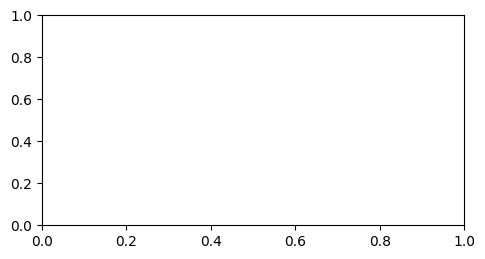

In [18]:
import matplotlib.pyplot as plt

# Plotting train and test losses over epochs
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Test Losses')
plt.legend()

# Plotting RMSE values over epochs
plt.subplot(2, 2, 2)
plt.plot(train_rmse_values, label='Train RMSE')
plt.plot(test_rmse_values, label='Test RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Train and Test RMSE')
plt.legend()

# Plotting R² values over epochs
plt.subplot(2, 2, 3)
plt.plot(train_r2_values, label='Train R²')
plt.plot(test_r2_values, label='Test R²')
plt.xlabel('Epochs')
plt.ylabel('R²')
plt.title('Train and Test R²')
plt.legend()

# Plotting MAPE values over epochs
plt.subplot(2, 2, 4)
plt.plot(train_mape_values, label='Train MAPE')
plt.plot(test_mape_values, label='Test MAPE')
plt.xlabel('Epochs')
plt.ylabel('MAPE')
plt.title('Train and Test MAPE')
plt.legend()

plt.tight_layout()
plt.savefig(f'{plot_path}/epoch_op_plot.png')
plt.show()
plt.close()

In [19]:
for i in range(len(y_test_unscaled)):
  print(f"{y_test_unscaled[i]}, {predictions_test_unscaled[i]}")

NameError: name 'y_test_unscaled' is not defined

In [29]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load the trained model
num_features = X_train_tensor.shape[2]
num_nodes = X_train_tensor.shape[1]
best_model_path = '/content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/best_model/best_model.pth'
print(f'best_model_path {best_model_path}')

model = AdvancedTemporalGraphNetwork(num_features=num_features, hidden_channels=16, num_nodes=num_nodes, dropout=0.2)
model.load_state_dict(torch.load(best_model_path, weights_only=True))  # Load the best model
model.eval()  # Set the model to evaluation mode




best_model_path /content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/best_model/best_model.pth


AdvancedTemporalGraphNetwork(
  (feature_reducer): Linear(in_features=10, out_features=16, bias=True)
  (graph_conv1): SAGEConv(16, 16, aggr=mean)
  (graph_conv2): SAGEConv(16, 16, aggr=mean)
  (dropout): Dropout(p=0.2, inplace=False)
  (temporal_lstm): LSTM(16, 16, num_layers=2, batch_first=True, dropout=0.2)
  (temporal_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
  )
  (prediction_head): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [32]:
def prepare_future_data(future_dates, sensor_ids, scalers_X, sensor_location_map):
    """
    Prepare future data for forecasting with actual temperature & humidity.
    Args:
        future_dates: List of future dates (datetime objects).
        sensor_ids: List of sensor IDs.
        scalers_X: Dictionary of scalers for each sensor.
        sensor_location_map: Dictionary mapping sensor_id to (longitude, latitude).
        df: DataFrame containing historical data.
    Returns:
        X_future_tensor: Tensor of future data for prediction.
    """
    # Create DataFrame for future timestamps and sensor IDs
    future_df = pd.DataFrame({
        'timestamp': np.repeat(future_dates, len(sensor_ids)),
        'sensor_id': np.tile(sensor_ids, len(future_dates))
    })

    # Get latest temperature & humidity readings per sensor
    latest_readings = df.groupby('sensor_id')[['temperature', 'humidity']].last()

    # Map temperature & humidity from historical data
    future_df['temperature'] = future_df['sensor_id'].map(lambda x: latest_readings.loc[x, 'temperature'] if x in latest_readings.index else np.nan)
    future_df['humidity'] = future_df['sensor_id'].map(lambda x: latest_readings.loc[x, 'humidity'] if x in latest_readings.index else np.nan)

    # Fill missing values with median (or any strategy)
    future_df['temperature'].fillna(future_df['temperature'].median(), inplace=True)
    future_df['humidity'].fillna(future_df['humidity'].median(), inplace=True)

    # Map longitude and latitude from sensor_location_map
    future_df['longitude'] = future_df['sensor_id'].map(lambda x: sensor_location_map[x]['longitude'] if x in sensor_location_map else None)
    future_df['latitude'] = future_df['sensor_id'].map(lambda x: sensor_location_map[x]['latitude'] if x in sensor_location_map else None)

    # Extract time-based features
    future_df['year'] = future_df['timestamp'].dt.year
    future_df['month'] = future_df['timestamp'].dt.month
    future_df['day_of_month'] = future_df['timestamp'].dt.day
    future_df['hour'] = future_df['timestamp'].dt.hour
    future_df['minute'] = future_df['timestamp'].dt.minute
    future_df['second'] = future_df['timestamp'].dt.second

    # Drop timestamp column
    future_df = future_df.drop(columns=['timestamp'])

    # Scale features using the same scalers used during training
    X_future_scaled = []
    for sensor_id in sensor_ids:
        df_sensor = future_df[future_df['sensor_id'] == sensor_id].drop(columns=['sensor_id'])
        X_scaled = scalers_X[sensor_id].transform(df_sensor.to_numpy())
        X_future_scaled.append(X_scaled)

    # Combine scaled data
    X_future_scaled = np.concatenate(X_future_scaled, axis=0)

    # Ensure divisibility by num_nodes (padding if necessary)
    total_samples = X_future_scaled.shape[0]
    remainder = total_samples % num_nodes
    if remainder != 0:
        num_dummy_rows = num_nodes - remainder
        dummy_rows = np.zeros((num_dummy_rows, num_features))  # Zero padding
        X_future_scaled = np.vstack([X_future_scaled, dummy_rows])

    X_future_scaled = X_future_scaled.reshape(-1, num_nodes, num_features)

    # Convert to tensor
    X_future_tensor = torch.tensor(X_future_scaled, dtype=torch.float32)

    return X_future_tensor


In [34]:
# Define future dates for forecasting (every 15 minutes for the next 7 days)
future_dates = pd.date_range(start=pd.Timestamp.now().floor('D') + pd.Timedelta(days=1),  # Start from next day
                             end=pd.Timestamp.now().floor('D') + pd.Timedelta(days=8),    # End after 7 days
                             freq='15min')  # Frequency: 15 minutes

print(f'len future_dates {len(future_dates)}')
print(f'len sensor_ids {len(sensor_ids)}')


# Selecting relevant columns
sensor_location_map = df[['sensor_id', 'longitude', 'latitude']]
# Dropping duplicate sensor_id rows
sensor_location_map = sensor_location_map.drop_duplicates(subset='sensor_id')

# Setting index and converting to dictionary
sensor_location_map = sensor_location_map.set_index('sensor_id')[['longitude', 'latitude']].to_dict(orient='index')
print(sensor_location_map)

# Prepare future data
X_future_tensor = prepare_future_data(future_dates, sensor_ids, scalers_X, sensor_location_map)

# Generate predictions for future dates
with torch.no_grad():
    future_predictions = model(X_future_tensor, edge_index, X_future_tensor)

# Unscale the predictions
future_predictions_unscaled = np.concatenate([
    scalers_y[sensor_id].inverse_transform(future_predictions[idx:idx+len(future_dates)].detach().numpy().reshape(-1, 1)).flatten()
    for idx, sensor_id in enumerate(sensor_ids)
], axis=0)

# Create a DataFrame to store the predictions
future_predictions_df = pd.DataFrame({
    'timestamp': np.repeat(future_dates, len(sensor_ids)),
    'sensor_id': np.tile(sensor_ids, len(future_dates)),
    'predicted_pm2p5': future_predictions_unscaled
})

print(future_predictions_df)
# Save the predictions to a CSV file
future_predictions_df.to_csv('/content/drive/MyDrive/Intellipaat-sem2/AirPollutionAnalysis/RG/pm2p5_output/future_predictions_15min.csv', index=False)

print("Future predictions saved to CSV.")

len future_dates 673
len sensor_ids 13
{350976650270090: {'longitude': 27.763986, 'latitude': -26.218879}, 350457790741209: {'longitude': 27.827818, 'latitude': -26.216588}, 350457791749920: {'longitude': 27.826879, 'latitude': -26.19333}, 350457790739948: {'longitude': 27.863264, 'latitude': -26.19094}, 350457790741191: {'longitude': 27.841915, 'latitude': -26.187931}, 350457790675282: {'longitude': 27.858468, 'latitude': -26.204235}, 350457790675332: {'longitude': 28.02784030713988, 'latitude': -26.19297587450942}, 350457791749938: {'longitude': 28.028561, 'latitude': -26.193147}, 350457791744376: {'longitude': 28.029644612240183, 'latitude': -26.185896602269175}, 350457791750134: {'longitude': 28.030310635279296, 'latitude': -26.186394046436483}, 350457791749821: {'longitude': 27.853998646034164, 'latitude': -26.196616341076925}, 350457791750035: {'longitude': 28.017517, 'latitude': -26.181013}, 350976650262543: {'longitude': 28.017968, 'latitude': -26.180701}}


<ipython-input-32-591d540070b4>:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  future_df['temperature'].fillna(future_df['temperature'].median(), inplace=True)
<ipython-input-32-591d540070b4>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

      timestamp        sensor_id  predicted_pm2p5
0    2025-02-10  350976650270090        15.551123
1    2025-02-10  350457790741209        15.665661
2    2025-02-10  350457791749920        16.138357
3    2025-02-10  350457790739948        16.702360
4    2025-02-10  350457790741191        16.638254
...         ...              ...              ...
8744 2025-02-17  350457791744376        18.859396
8745 2025-02-17  350457791750134        18.802650
8746 2025-02-17  350457791749821        18.890408
8747 2025-02-17  350457791750035        18.953358
8748 2025-02-17  350976650262543        18.971565

[8749 rows x 3 columns]
Future predictions saved to CSV.


save with actual data